## TASK 3 - Scene recognition with Bag of Visual Words

Group Number: 14


### 1 Data import and Preparation

Complete the class ***SceneDataset*** in ***dataset.py*** and load the training and test dataset. (images and class labels)

In [1]:
%load_ext autoreload
%autoreload 1
%aimport features, dataset, utils
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
import numpy as np
import features
import dataset
import utils
import os

In [ ]:
if not os.path.exists(os.path.join(os.getcwd(), 'results')):
    os.makedirs(os.path.join(os.getcwd(), 'results'))

#student_code start
train_dataset = dataset.SceneDataset("data/scene/train")
train_images, train_labels = train_dataset.get_data()

own_class_names = train_dataset.get_class_names()

test_dataset = dataset.SceneDataset("data/scene/test")
test_images, test_labels = test_dataset.get_data()

# Note, that we have 10 categories and for each one exists 160 training and 40 test samples. 
# This leads to 1600 training and 400 test samples. 

#student_code end
print('Imported test data: ',len(test_images))
print('Imported training data: ', len(train_images))
print(own_class_names)


Imported test data:  400
Imported training data:  1600
['bedroom', 'coast', 'forest', 'kitchen', 'livingroom', 'mountain', 'office', 'store', 'street', 'tallbuilding']


###  2 Build Vocabulary and Clusters

Extract SIFT features from the training data using ***features.extract_dsift(..)*** and then utilize the descriptors to generate visual words with ***KMeans(...).fit(...).cluster_centers_*** from ***sklearn.neighbors***. Set the sample size per image at about **100** and a step size around **5**. For cluster size, try a value around **50**. You can adapt the paramater to achieve better results. If clustering takes too long, have a look at the parameters **n_init** and **max_iter** of ***KMeans(...)***.

_***HINT:***_
***KMeans(..)*** expects the features to be a stacked 2D matrix instead of a list (np.vstack(...)).


In [3]:
#student code start

# 1. Extract SIFT features
descriptors = features.extract_dsift(train_images, stepsize=5, num_samples=100)

# 2. Generate visual words by using k-means and descriptors
descriptors_stacked = np.vstack(descriptors)

kmeans = KMeans(n_clusters=50) # n_init=10, max_iter=300)
kmeans.fit(descriptors_stacked)

vocabulary = kmeans.cluster_centers_
print("Vocabulary: ", vocabulary)

#student code end

DSIFT Extraction: 1.4362951000075554  seconds


c:\Users\melan\Documents\uni\Computer Vision\ComputerVision_Group14_Assignment2\Assignment2\A2\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Vocabulary:  [[ 9.5965605 10.040626  16.954494  ... 24.437574  18.971386  13.003902 ]
 [20.503525  12.040893  12.629427  ... 11.6696    13.227058  26.45555  ]
 [ 9.013859   8.85243   17.386288  ... 14.103942  27.654205  11.610339 ]
 ...
 [14.809589  18.46632   38.3135    ... 16.169863  32.098976  12.197724 ]
 [43.350758  37.97224   30.968378  ... 14.891866  18.476208  13.019794 ]
 [18.217379  22.53799   22.905937  ... 11.220817  16.939758  19.310001 ]]


###  3 Classification

Generat a histogram per image using the centroids. First extract the dense SIFT features of the training set again. This time use a smaller stepsize (eg. 1 or 2) and take all samples.

After, implement ***count_visual_words(..)*** in ***features.py*** to obtain a histogram per image. Build a kNN classifier with ***KNeighborsClassifier(..)*** and fit the the model with the histogram data of the training images and training labels. Set the neighbourhood size to **3**.


In [4]:
#student code start
print("Determine train BoW descriptors")
descriptors_all_samples = features.extract_dsift(train_images, stepsize=2)
# Generate histogram
histograms = features.count_visual_words(descriptors_all_samples, vocabulary)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(histograms, train_labels)

#student code end

Determine train BoW descriptors
DSIFT Extraction: 21.674916799995117  seconds
Counting visual words: 10.008014500010177  seconds


KNeighborsClassifier(n_neighbors=3)

### 4 Evaluation

Examine the accuracy of your model by extracting the dense SIFT points of the test set with the same stepsize as before, generate the histogams and predict the labels of the test set with the previously fitted classifier. Plot your results with ***utils.plot_confusion_matrix(..)***.

_***HINT:***_
Use the methods ***predict(..)*** and ***score(..)*** on the KNN classifier.


***Submission:*** Save the confusion matrix with the KNN score as **task3_accuracy_test_data.png** using ***utils.plot_confusion_matrix(..)***.



Determine test BoW descriptors
DSIFT Extraction: 5.438971800002037  seconds
Counting visual words: 2.8383347999915713  seconds


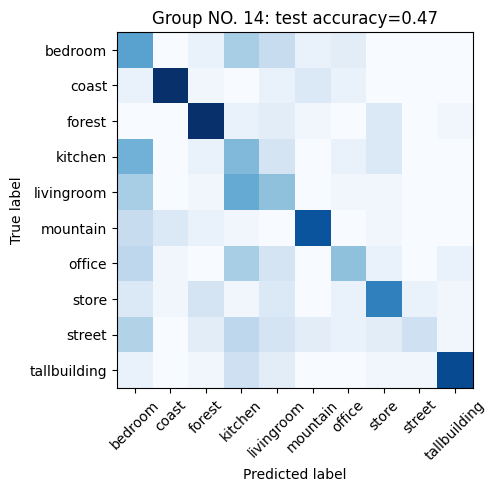

In [5]:
#student code start
print("Determine test BoW descriptors")
test_descriptors = features.extract_dsift(test_images, stepsize=2)
test_histograms = features.count_visual_words(test_descriptors, vocabulary)

predicted_labels = knn.predict(test_histograms)
score = knn.score(test_histograms, test_labels)

utils.plot_confusion_matrix(test_labels, predicted_labels, score, own_class_names, "Group NO. 14", "task3_accuracy_test_data.png")
#student code end

***
#### Q1: Analyze the confusion matrix. Are there classes which can be more easily identified than others. What could be the reason? What classes perform worst, and explain your answer.


#### Answer:
#### Good Performance:
- Easily identified classes are: tall building, mountain, forest and coast.
- They show dark blue squares on the diagonal (without noise) and indicating a high number of correct predictions.
- These categories represent outdoor scenes with textures and structures that the SIFT descriptors determines very well.

#### Bad Performance:
- The categories perform quite bad: bedroom, kitchen, living room and office.
- They have lighter blue squares on the diagonal and significant noise along the coloumns/rows.
- These categories are all indoor scenes and share very similar local visual features, e.g. furniture.


Take some own test images and investigate if they can be correctly classified with you trained model. For instance, take a photo of your own kitchen or living room and classify it. You should at least test one photo from three of the ten categories. Make sure the images are resized and cropped to 100x100.

***Submission:*** Save the confusion matrix with the model score as **task3_accuracy_custom_data.png** using ***utils.plot_confusion_matrix(..)***.

In [ ]:
#student code start
# own_test has the same structure as test directory
own_test_dataset = dataset.SceneDataset("data/scene/own_test")
own_test_images, own_test_labels = own_test_dataset.get_data()

own_class_names = own_test_dataset.get_class_names()
# images are resized to (100, 100) in SceneDataset
print('Imported OWN test data: ',len(own_test_images))

#student code start
own_test_descriptors = features.extract_dsift(own_test_images, stepsize=2)
own_test_histograms = features.count_visual_words(own_test_descriptors, vocabulary)

own_predicted_labels = knn.predict(own_test_histograms)
own_score = knn.score(own_test_histograms, own_test_labels)

utils.plot_confusion_matrix(own_test_labels, own_predicted_labels, own_score, own_class_names, "Group NO. 14", "task3_accuracy_custom_data.png")

'''
Tested
Used 3 different test images: 
- living room (but sofa is seen from behind)
- office (desk, chair, laptop)
- kitchen

Results:
- kitchen is identified correctly
- living room is detected as tall bluilding (in first run), now it is detected as store
- office is detected as mountain (maybe because of curvy LED-Streifen above desk)
'''

#student code end

Imported OWN test data:  3
DSIFT Extraction: 0.032919199991738424  seconds
Counting visual words: 0.01755109999794513  seconds


IndexError: list index out of range

### 5 Beyond Bag Of Words: Vector of Locally Aggregated Descriptors (VLAD)

Finally, we want to investigate an extension of the traditional bag of words model, called **Vector of Locally Aggregated Descriptors (VLAD)**, which not only considers the cluster assignment, but also uses the distance to the nearest centroid (refered to as **residual**).

Implement the VLAD algorithm in **features.calculate_vlad_descriptors** according to the task description and run the whole classification again by replacing the bag of words descriptors with VLAD. Compare the performance and discuss the advantages and disadvantages. Can you think of any further extensions?

***Submission:*** Save the confusion matrix with the model score as **task3_accuracy_vlad_descriptor.png** using ***utils.plot_confusion_matrix(..)***.

Determine train VLAD descriptors
Counting visual words: 144.82459856100013  seconds
Determine test VLAD descriptors
Counting visual words: 36.00686316300016  seconds


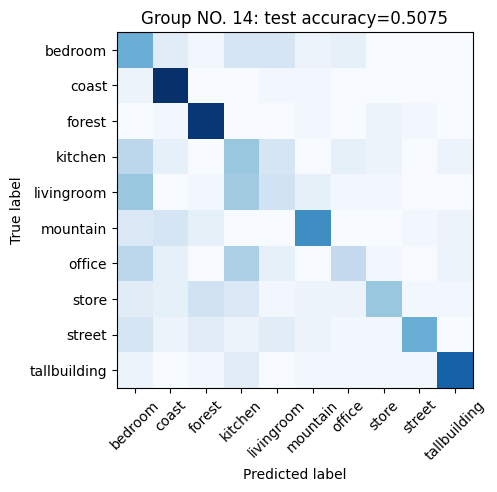

'\nPerformance:\n- Accuracy: VLAD outperforms classical BoW by + 7.5 %\n- Runtime: BoW (~ 34 seconds) is quite faster than VLAD (~ 3 seconds)\n  - BOW  train:  15.517  s \n  - BOW  test :   3.0355 s\n  - VLAD train: 138.319  s\n  - VLAD test :  34.458  s  \n\nAdvantages:\nBoW:\n - simple and fast computation (feature vector length = number of clusters)\n\nVLAD:\n  - Higher accuracy because it retains local feature details (residuals) instead of just counting them\n\nDisadvantages:\nBoW:\n  - Lose information about how well a feature fits into a cluster, count only the match\n\nVLAD:\n  - Calculating residuals and handling large feature vectors (more memory, num of clusters * 128) takes much longer\n'

In [ ]:
#student code start
print("Determine train VLAD descriptors")
train_histograms_vlad = features.calculate_vlad_descriptors(descriptors_all_samples, vocabulary)

knn_vlad = KNeighborsClassifier(n_neighbors=3)
knn_vlad.fit(train_histograms_vlad, train_labels)

print("Determine test VLAD descriptors")
test_histograms_vlad = features.calculate_vlad_descriptors(test_descriptors, vocabulary)


predicted_labels_vlad = knn_vlad.predict(test_histograms_vlad)
score_vlad = knn_vlad.score(test_histograms_vlad, test_labels)

utils.plot_confusion_matrix(test_labels, predicted_labels_vlad, score_vlad, own_class_names, "Group NO. 14", "task3_accuracy_vlad_descriptor.png")

'''
Performance:
- Accuracy: VLAD outperforms classical BoW by + 7.5 %
- Runtime: BoW (~ 34 seconds) is quite faster than VLAD (~ 3 seconds)
  - BOW  train:  15.517  s / second run:  13.218 s
  - BOW  test :   3.0355 s / second run:   2.460 s
  - VLAD train: 138.319  s / second run: 144.826 s
  - VLAD test :  34.458  s / second run:  36.007 s 


Advantages:
BoW:
 - simple and fast computation (feature vector length = number of clusters)

VLAD:
  - Higher accuracy because it retains local feature details (residuals) instead of just counting them

Disadvantages:
BoW:
  - Lose information about how well a feature fits into a cluster, count only the match

VLAD:
  - Calculating residuals and handling large feature vectors (more memory, num of clusters * 128) takes much longer
'''

#student code end